In [57]:
import pandas as pd

In [58]:
mass_balance_path = "mass_balance.csv"
df = pd.read_csv(mass_balance_path)
# print(df.columns)
# print(df.head())


In [ ]:
#I will recreate the calculations to make sure they are correct
#first, determine the change in lake elevation (dz)
vet_df = pd.DataFrame(df[["Month","Level as of 1st","Precipitation(Inches)"]])

#change column names for workability
vet_df.columns = ["date","elev","precip(in)"]
print

#convert inches to ft
vet_df["precip(ft)"] = vet_df['precip(in)'] / 12

#derive dz
vet_df["dz"] = vet_df["elev"].shift(-1) - vet_df["elev"]
# print(vet_df.head())

#now subtract the change in elevation from the precipitation - negative loss means lake levels went up
vet_df["loss"] = vet_df["precip(ft)"] - vet_df["dz"]
# print(vet_df.head())


       date     elev  precip(in)  precip(ft)    dz
0  1/1/2014  4193.90        1.20    0.100000  0.18
1  2/1/2014  4194.08        1.57    0.130833  0.23
2  3/1/2014  4194.31        1.11    0.092500  0.16
3  4/1/2014  4194.47        1.55    0.129167  0.03
4  5/1/2014  4194.50        1.04    0.086667 -0.26


In [ ]:
vet_df["avg_12mo_loss"] = 

Slope: -0.0004 ft/month
Slope: -0.00 ft/year


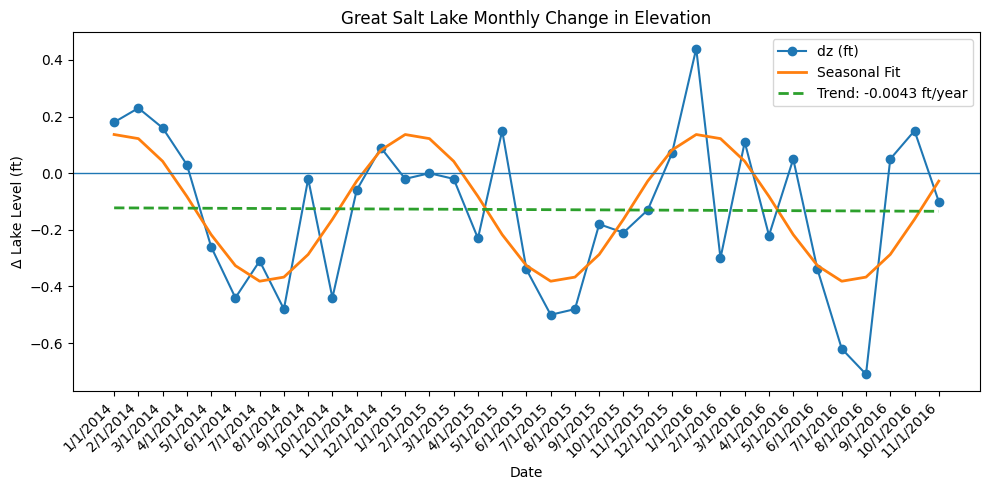

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = vet_df.dropna(subset=["dz"]).copy()

# Time index in months
t = np.arange(len(plot_df))

# Observations
y = plot_df["dz"].values

omega = 2 * np.pi / 12

# Design matrix WITH linear trend
X = np.column_stack([
    np.sin(omega * t),
    np.cos(omega * t),
    t,
    np.ones(len(t))
])

# Least squares fit
coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
A, B, D, C = coef

# Fits
dz_seasonal = A * np.sin(omega * t) + B * np.cos(omega * t) + C
dz_seasonal_trend = (
    A * np.sin(omega * t) +
    B * np.cos(omega * t) +
    D * t +
    C
)

# Linear trend only (for plotting)
linear_trend = D * t + C

slope_ft_per_month = D
slope_ft_per_year = D * 12

print(f"Slope: {slope_ft_per_month:.4f} ft/month")
print(f"Slope: {slope_ft_per_year:.2f} ft/year")

slope_label = f"Trend: {slope_ft_per_year:.4f} ft/year"

plt.figure(figsize=(10, 5))
plt.plot(plot_df["date"], y, marker="o", label="dz (ft)")
plt.plot(plot_df["date"], dz_seasonal, linewidth=2, label="Seasonal Fit")
plt.plot(plot_df["date"], linear_trend, linestyle="--", linewidth=2, label=slope_label)

plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Δ Lake Level (ft)")
plt.title("Great Salt Lake Monthly Change in Elevation")

plt.legend()


plt.tight_layout()
plt.show()



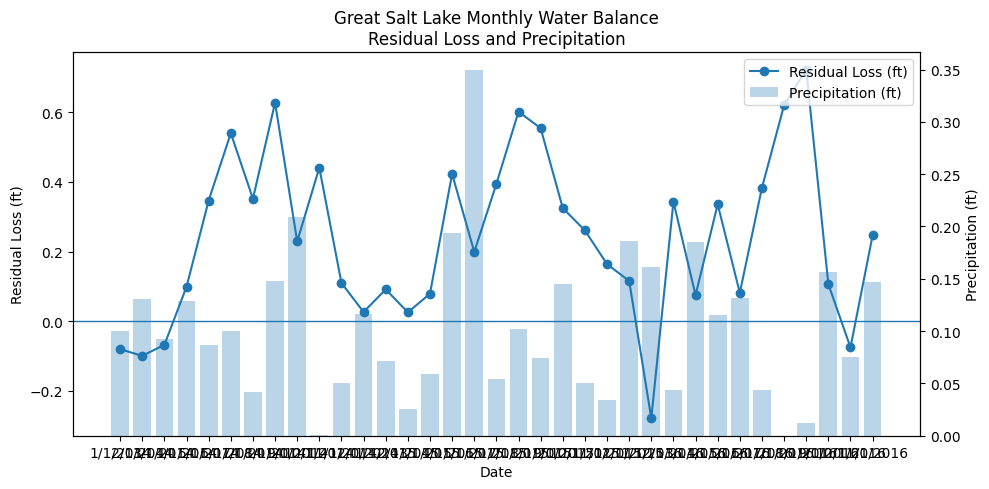

In [70]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = vet_df.dropna(subset=["loss", "precip(ft)"]).copy()

plt.figure(figsize=(10, 5))

# Primary axis: loss
plt.plot(
    plot_df["date"],
    plot_df["loss"],
    marker="o",
    label="Residual Loss (ft)"
)

plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Residual Loss (ft)")

# Secondary axis: precipitation
ax = plt.gca()
ax2 = ax.twinx()

ax2.bar(
    plot_df["date"],
    plot_df["precip(ft)"],
    alpha=0.3,
    label="Precipitation (ft)"
)

ax2.set_ylabel("Precipitation (ft)")

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Great Salt Lake Monthly Water Balance\nResidual Loss and Precipitation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


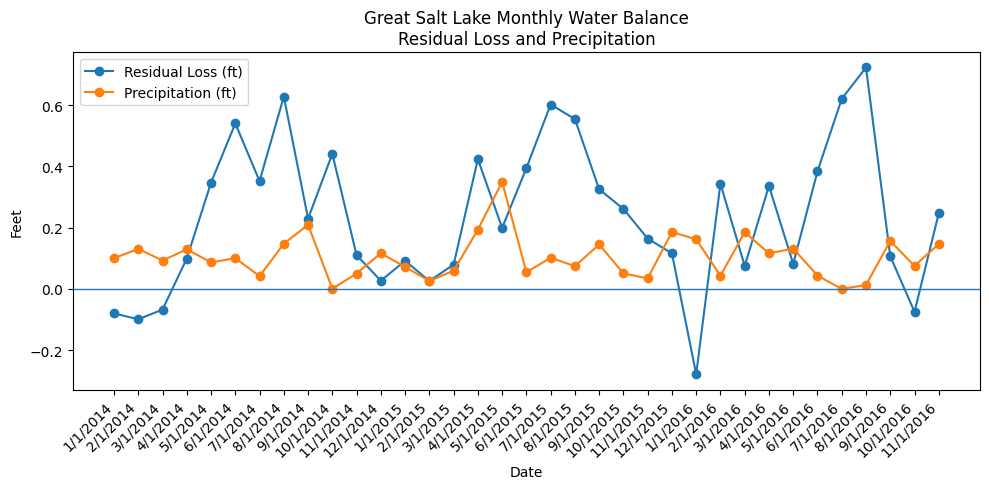

In [72]:
import matplotlib.pyplot as plt

plot_df = vet_df.dropna(subset=["loss", "precip(ft)"]).copy()

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["date"],
    plot_df["loss"],
    marker="o",
    label="Residual Loss (ft)"
)

plt.plot(
    plot_df["date"],
    plot_df["precip(ft)"],
    marker="o",
    label="Precipitation (ft)"
)

plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Feet")
plt.title("Great Salt Lake Monthly Water Balance\nResidual Loss and Precipitation")

plt.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
